#📌 Extracción

In [9]:
import requests
import json

url = 'https://raw.githubusercontent.com/Coobaltoo13/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json' # Replace with your raw GitHub URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    json_data = response.json()
    print("JSON data loaded successfully as a Python dictionary.")
    # You can now work with json_data as a dictionary
    # print(json_data)
else:
    print(f"Failed to fetch file. Status code: {response.status_code}")

JSON data loaded successfully as a Python dictionary.


#🔧 Transformación

In [10]:
import pandas as pd

df = pd.DataFrame(json_data)
print("json_data successfully converted to a pandas DataFrame named 'df'.")
print(df.head())

json_data successfully converted to a pandas DataFrame named 'df'.
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '..

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [12]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [13]:
from pandas import json_normalize
import pandas as pd

# Re-initialize df from json_data to ensure original nested columns are present
df = pd.DataFrame(json_data)

# Normalize 'customer' column
customer_df = json_normalize(df['customer'])

# Normalize 'phone' column
phone_df = json_normalize(df['phone'])

# Normalize 'internet' column
internet_df = json_normalize(df['internet'])

# Normalize 'account' column
account_df = json_normalize(df['account'])

# Concatenate the new dataframes with the original df and drop the nested columns
df = pd.concat([df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)

# Convert 'Charges.Total' to numeric, coercing errors
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Convert 'SeniorCitizen' to boolean
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)

print("Dictionary columns expanded and data types adjusted.")
print(df.head())
print(df.info())

Dictionary columns expanded and data types adjusted.
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female          False     Yes        Yes       9   
1  0003-MKNFE    No    Male          False      No         No       9   
2  0004-TLHLJ   Yes    Male          False      No         No       4   
3  0011-IGKFF   Yes    Male           True     Yes         No      13   
4  0013-EXCHZ   Yes  Female           True     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes   

In [14]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,False,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,False,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,False,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,True,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,True,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [15]:
df.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data into training and testing sets
# Using X_selected (features after selection) and y (encoded Churn)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize a RandomForestClassifier with class_weight='balanced'
# This helps address imbalanced datasets by automatically adjusting weights
# inversely proportional to class frequencies.
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully with balanced class weights.")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (churn)

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix for a clearer view
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'X_selected' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances:")
print(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Descriptive Statistics for Numerical Features ---")
# Describe numerical columns
print(df.describe())

print("\n--- Descriptive Statistics for Categorical Features ---")
# Describe categorical (object) columns
print(df.describe(include='object'))

print("\n--- Value Counts for Boolean/Binary Features ---")
# For boolean or binary-like features, value_counts provides more insight
print("\nSeniorCitizen Value Counts:")
print(df['SeniorCitizen'].value_counts())

# You can also look at specific categorical columns in more detail
print("\nGender Value Counts:")
print(df['gender'].value_counts())

print("\nContract Type Value Counts:")
print(df['Contract'].value_counts())


In [19]:
import numpy as np

# Fill missing values in 'Charges.Total' with the mean
df['Charges.Total'] = df['Charges.Total'].replace(' ', np.nan) # Replace spaces with NaN first if any
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].mean())
print("Missing values in 'Charges.Total' filled with the mean.")

Missing values in 'Charges.Total' filled with the mean.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer

# Separate features (X) and target (y)
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Encode target variable 'Churn' (Yes/No to 1/0)
le = LabelEncoder()
y = le.fit_transform(y)
print(f"Target variable 'Churn' encoded: {le.classes_} -> {le.transform(le.classes_)}")

# Identify categorical and numerical columns in X
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=[np.number]).columns

# Create a ColumnTransformer for one-hot encoding categorical features
# and passing through numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This part can be tricky, especially with handle_unknown='ignore'
# A more robust way would be to get feature names after fit

# For simplicity, let's just use the transformed array for SelectKBest directly
# If feature names are needed for analysis later, a pipeline would be better

print("Categorical features encoded and numerical features passed through.")
print(f"Shape of X_processed: {X_processed.shape}")

Target variable 'Churn' encoded: ['' 'No' 'Yes'] -> [0 1 2]
Categorical features encoded and numerical features passed through.
Shape of X_processed: (7267, 46)


In [21]:
# Perform feature selection using SelectKBest
k_best_selector = SelectKBest(f_classif, k=15) # Select top 15 features
X_selected = k_best_selector.fit_transform(X_processed, y)

# Get the indices of the selected features
selected_feature_indices = k_best_selector.get_support(indices=True)

# Get the feature names after preprocessing, before selection
# This requires knowing the order of columns from ColumnTransformer

# Get original numerical feature names
original_numerical_features = list(numerical_features)

# Get one-hot encoded feature names
one_hot_encoder = preprocessor.named_transformers_['cat']
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)

all_processed_feature_names = original_numerical_features + list(encoded_feature_names)

# Get the names of the selected features
selected_feature_names = [all_processed_feature_names[i] for i in selected_feature_indices]

print(f"Selected {len(selected_feature_names)} features:")
for feature_name in selected_feature_names:
    print(f"- {feature_name}")

print(f"Shape of X_selected (features after selection): {X_selected.shape}")

Selected 15 features:
- tenure
- InternetService_Fiber optic
- OnlineSecurity_No
- OnlineSecurity_No internet service
- OnlineBackup_No
- OnlineBackup_No internet service
- DeviceProtection_No
- DeviceProtection_No internet service
- TechSupport_No
- TechSupport_No internet service
- StreamingTV_No internet service
- StreamingMovies_No internet service
- Contract_Month-to-month
- Contract_Two year
- PaymentMethod_Electronic check
Shape of X_selected (features after selection): (7267, 15)


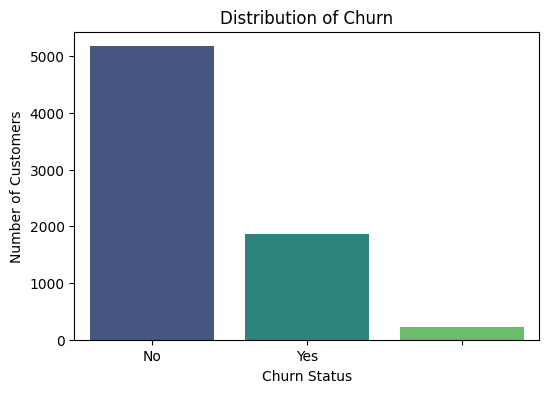

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

Training LGBMClassifier to get feature importances...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 101
[LightGBM] [Info] Number of data points in the train set: 5813, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBMClassifier trained successfully.

Top 10 Feature Importances from LGBMClassifier:
                               Feature  Importance
0                               tenure        4754
14      PaymentMethod_Electronic check         645
1          InternetService_Fiber optic         620
4                      OnlineBackup_No         539
8                       TechSupport_No         534
2                    OnlineSecurity_No   

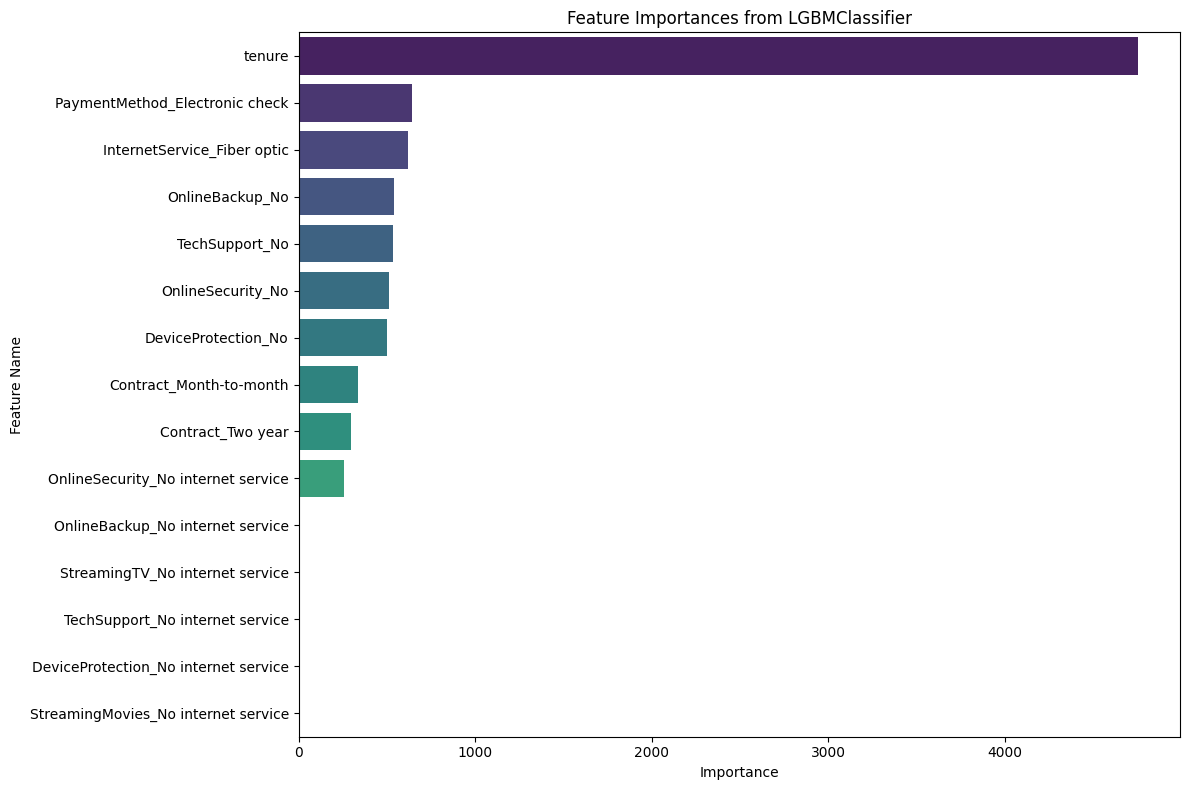

In [34]:
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Training LGBMClassifier to get feature importances...")

# Initialize and train the LGBMClassifier
# We'll use class_weight='balanced' here as well, similar to RandomForest
lgbm_model = LGBMClassifier(class_weight='balanced', random_state=42)
lgbm_model.fit(X_train, y_train)

print("LGBMClassifier trained successfully.")

# Get feature importances
feature_importances_lgbm = lgbm_model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df_lgbm = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances_lgbm
})

# Sort the DataFrame by importance in descending order
feature_importance_df_lgbm = feature_importance_df_lgbm.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("\nTop 10 Feature Importances from LGBMClassifier:")
print(feature_importance_df_lgbm.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_lgbm, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances from LGBMClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [24]:
df.customerID.value_counts()

,count
customerID,
9995-HOTOH,1
0002-ORFBO,1
0003-MKNFE,1
9970-QBCDA,1
9968-FFVVH,1
...,...
0014-BMAQU,1
0013-SMEOE,1
0013-MHZWF,1


In [25]:
print("Consistency check for 'gender' column:")
print(df.gender.value_counts())
print("\nConsistency check for 'Churn' column:")
print(df.Churn.value_counts())

Consistency check for 'gender' column:
gender
Male      3675
Female    3592
Name: count, dtype: int64

Consistency check for 'Churn' column:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [26]:
import numpy as np

# Eliminate duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"Removed {duplicates_removed} duplicate rows.")

# Handle inconsistencies in 'Churn' column (empty strings)
print(f"\nInitial Churn value counts:\n{df['Churn'].value_counts(dropna=False)}")

# First, strip any leading/trailing whitespace from the Churn column
df['Churn'] = df['Churn'].str.strip()

# Now replace true empty strings ('') with NaN
df['Churn'] = df['Churn'].replace('', np.nan)

churn_nan_count = df['Churn'].isnull().sum()
df.dropna(subset=['Churn'], inplace=True)
print(f"Removed {churn_nan_count} rows with empty 'Churn' values.")
print(f"Updated Churn value counts:\n{df['Churn'].value_counts(dropna=False)}") # Use dropna=False to confirm no NaNs are left

# Standardize string values (lowercase and strip whitespace) for consistency
# Exclude 'customerID' as it's an identifier and 'Churn' as it's already handled
for col in df.select_dtypes(include='object').columns:
    if col not in ['customerID', 'Churn']:
        df[col] = df[col].str.lower().str.strip()
print("\nObject columns standardized to lowercase and whitespace stripped (excluding customerID and Churn).")
print(f"New DataFrame shape after cleaning: {df.shape}")

Removed 0 duplicate rows.

Initial Churn value counts:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
Removed 224 rows with empty 'Churn' values.
Updated Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Object columns standardized to lowercase and whitespace stripped (excluding customerID and Churn).
New DataFrame shape after cleaning: (7043, 21)


#📊 Carga y análisis

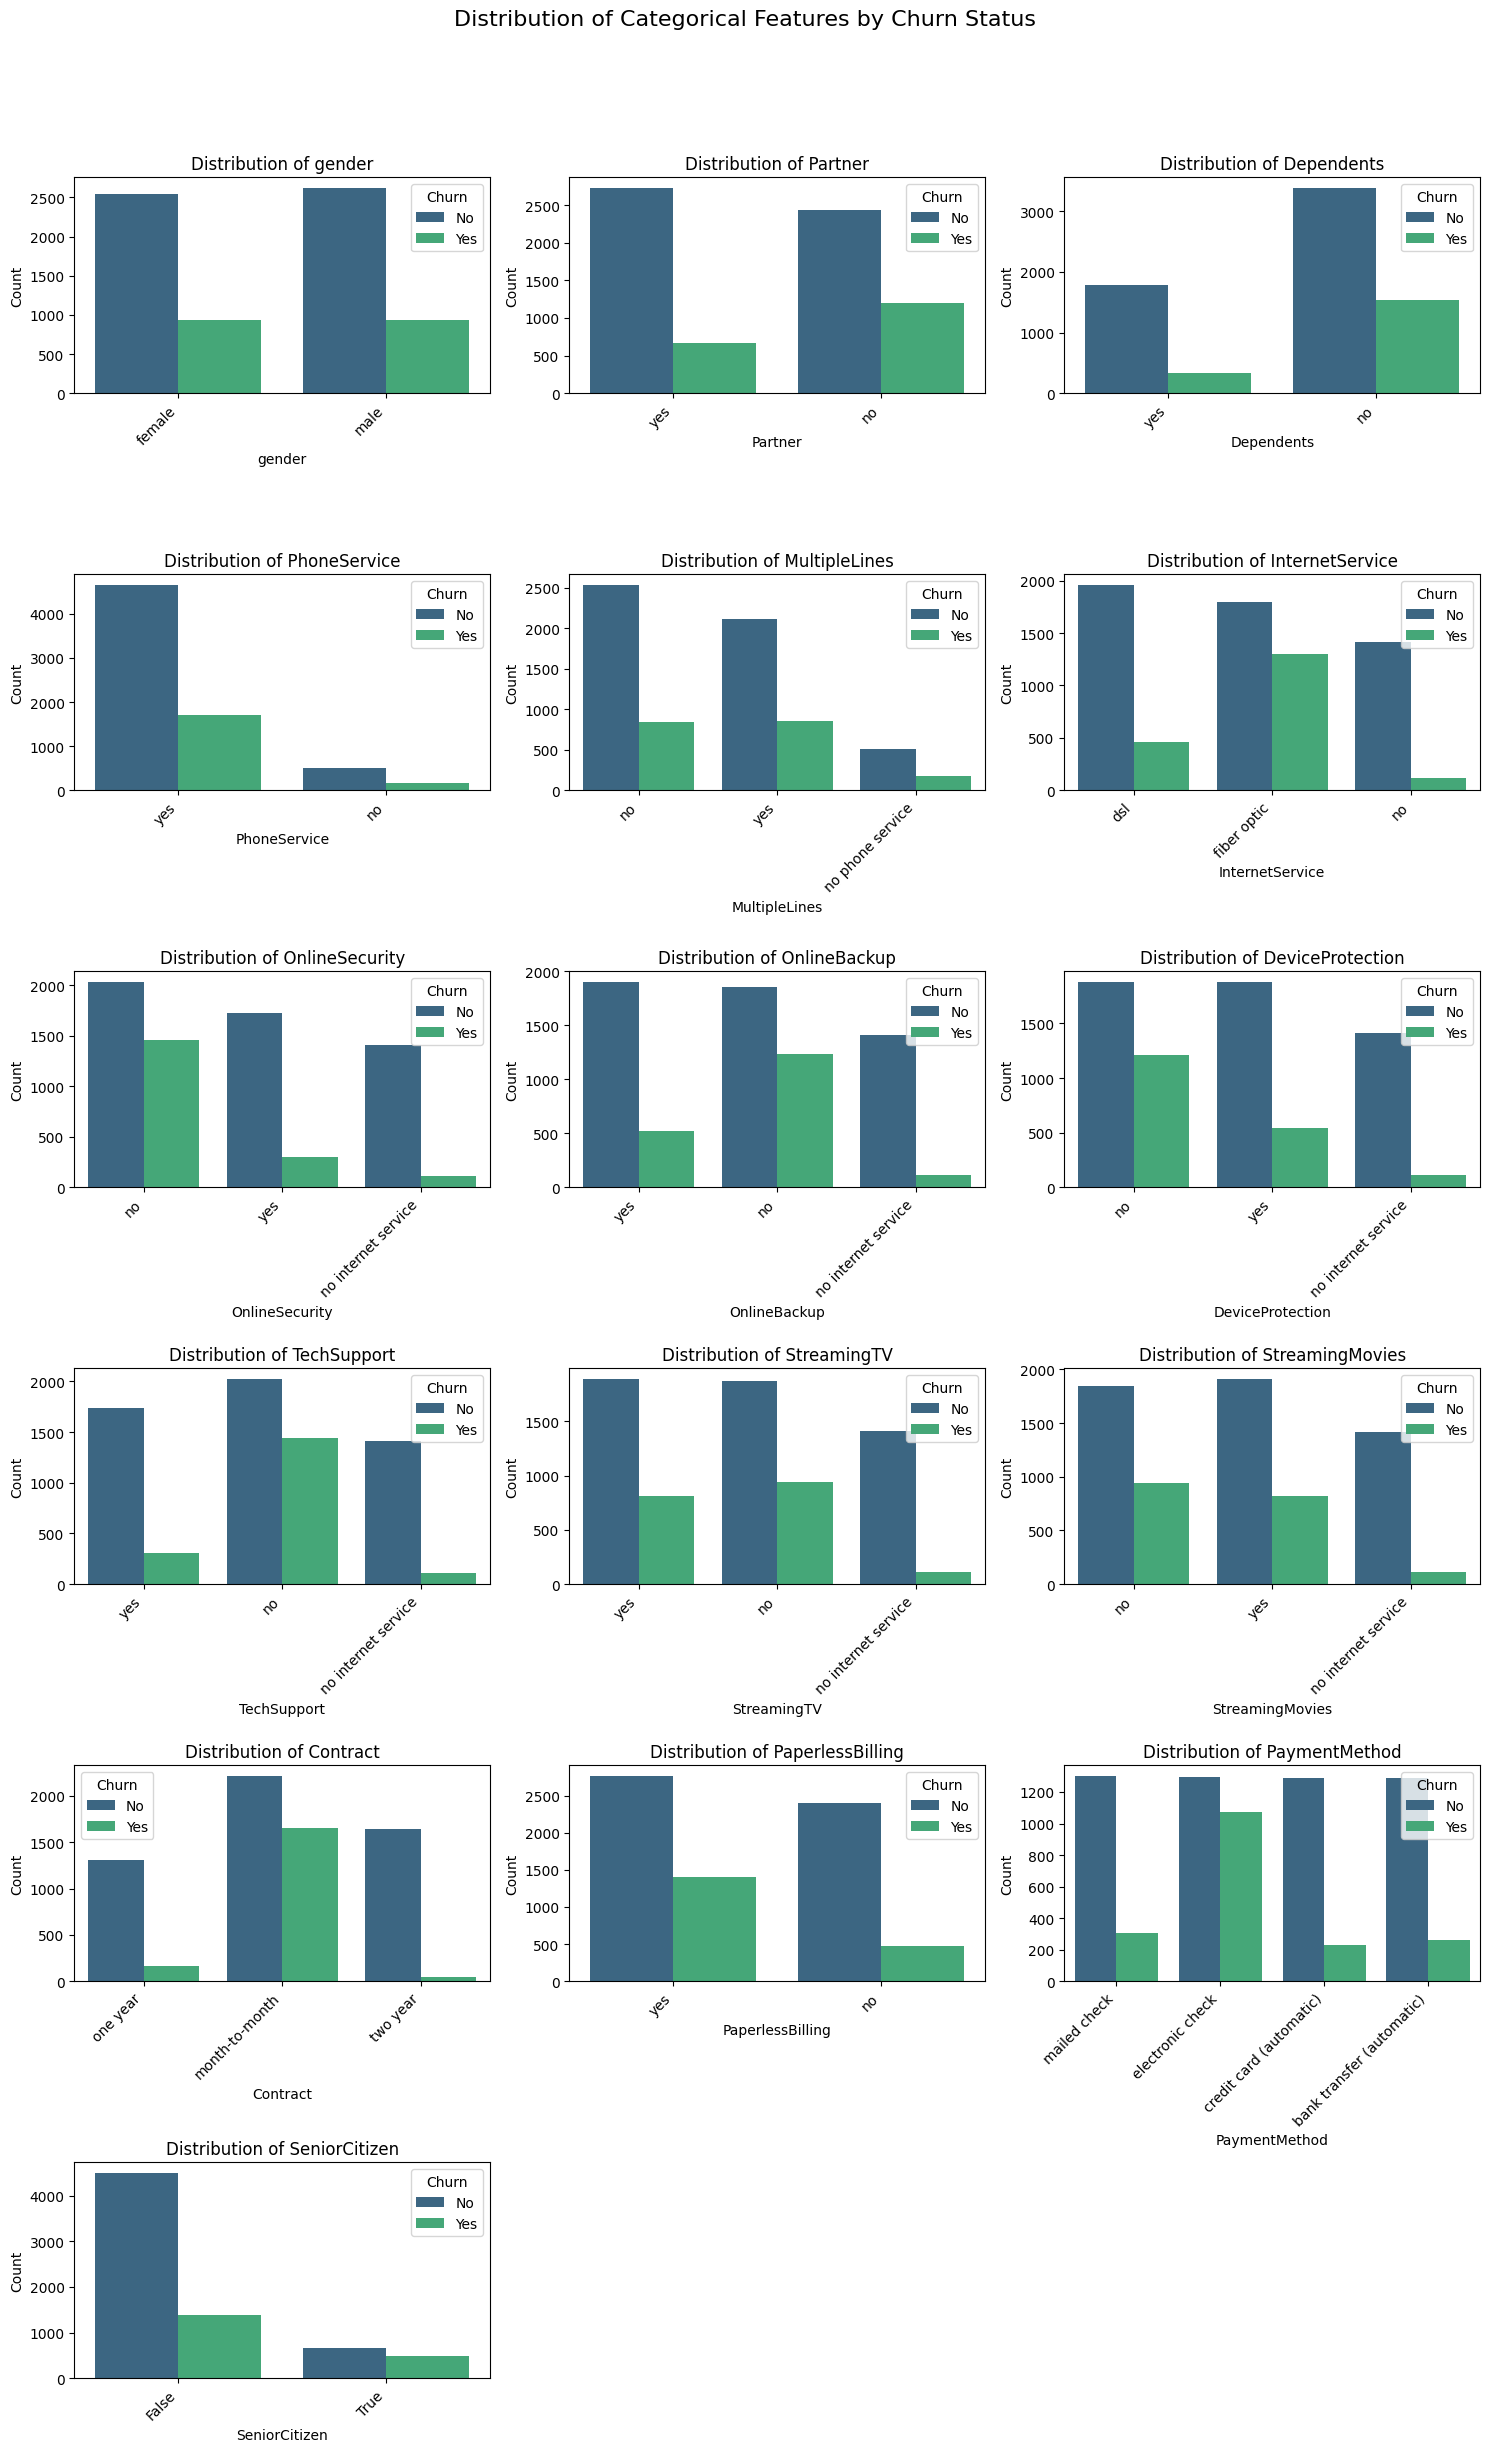

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features.remove('customerID') # Remove customerID as it's a unique identifier
categorical_features.remove('Churn')      # Remove Churn as it's the target variable

# Adding SeniorCitizen as a categorical for visualization purposes
categorical_features.append('SeniorCitizen')

# Determine the number of rows and columns for the subplot grid
n_features = len(categorical_features)
n_cols = 3  # You can adjust this number
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plt.suptitle('Distribution of Categorical Features by Churn Status', y=1.02, fontsize=16)

for i, feature in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=feature, hue='Churn', data=df, palette='viridis', legend=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

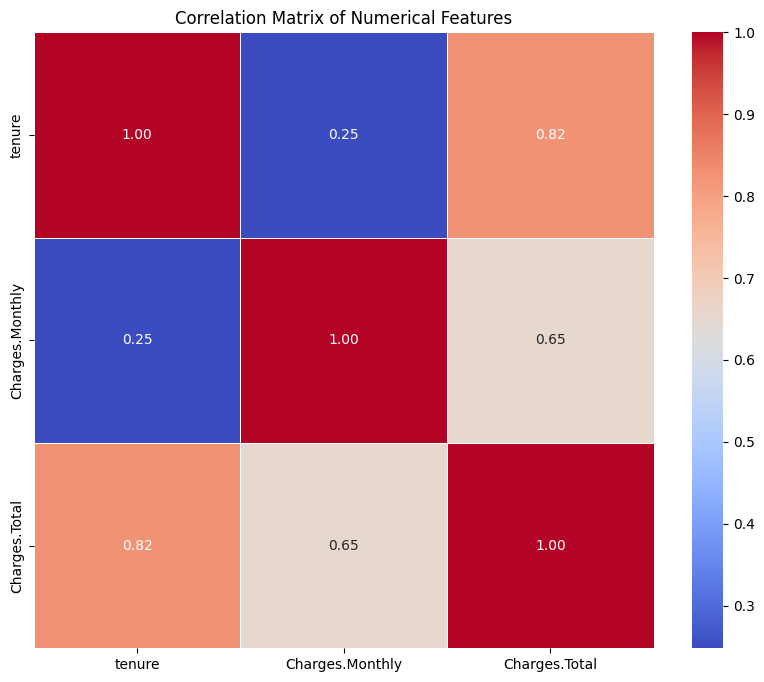

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns from the DataFrame
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

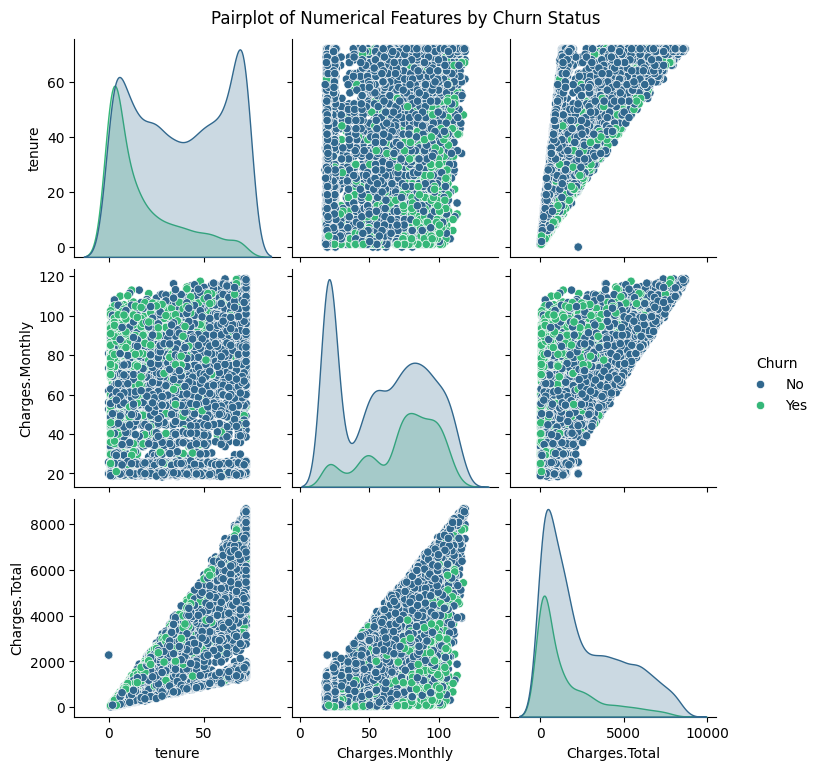

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns and the 'Churn' column for the pairplot
numerical_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']
pairplot_df = df[numerical_cols + ['Churn']]

# Create the pairplot with 'Churn' as the hue
sns.pairplot(pairplot_df, hue='Churn', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Churn Status', y=1.02) # Adjust suptitle position
plt.show()

In [30]:
df.to_csv('df_cleaned.csv', index=False)

#📄Informe final

DESAFIO PARTE 2

In [31]:
!pip install lazypredict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.4 MB/s eta 0:00:00


In [33]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# Re-split the data into training and testing sets to ensure variables are defined
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Note: LazyPredict works best with numerical data. Our X_selected is already numerical.

# Initialize LazyClassifier
# verbose=0: suppresses output during fitting
# ignore_warnings=True: ignores common warnings
# custom_metric: Can specify a custom metric, but default ROC AUC is good for imbalanced data.
clf = LazyClassifier(verbose=0, ignore_warnings=True, random_state=42)

# Fit all models and get predictions
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print("LazyPredict has evaluated several classification models.")
print("Here are the top-performing models:")
display(models)

Shape of X_train: (5813, 15)
Shape of X_test: (1454, 15)
Shape of y_train: (5813,)
Shape of y_test: (1454,)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 116
[LightGBM] [Info] Number of data points in the train set: 5813, number of used features: 15
[LightGBM] [Info] Start training from score -3.480466
[LightGBM] [Info] Start training from score -0.339643
[LightGBM] [Info] Start training from score -1.357971
LazyPredict has evaluated several classification models.
Here are the top-performing models:


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
BernoulliNB,0.69,0.50,None,0.70,0.03
PassiveAggressiveClassifier,0.71,0.50,None,0.71,0.06
NearestCentroid,0.61,0.49,None,0.64,0.03
GaussianNB,0.63,0.48,None,0.63,0.03
SGDClassifier,0.76,0.48,None,0.75,0.16
LGBMClassifier,0.77,0.48,None,0.75,0.62
AdaBoostClassifier,0.77,0.48,None,0.75,0.44
LinearDiscriminantAnalysis,0.77,0.48,None,0.75,0.10
CalibratedClassifierCV,0.77,0.48,None,0.76,0.24
